# Saguaro Stem and Bud Analysis 2016 - 2026

## Load Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import scikit_posthocs as sp
from sklearn.linear_model import LinearRegression
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [2]:
# load data into pandas dataframe
df = pd.read_csv('Saguaro Bud Counts - Bud and Stem Counts.csv')
# fix data
df = df.drop(columns=['Unnamed: 4'])
df.loc[df['Stem Count'] == 0, 'Stem Count'] = 1
df.head()

,Image,Year,Bud Count,Stem Count
0,15,2016,0,1
1,18,2016,9,9
2,19,2016,11,6
3,20,2016,51,3
4,21,2016,3,1


In [3]:
# make new column buds/stems
df['buds/stems'] = df['Bud Count'] / df['Stem Count']
df.head()

,Image,Year,Bud Count,Stem Count,buds/stems
0,15,2016,0,1,0.000000
1,18,2016,9,9,1.000000
2,19,2016,11,6,1.833333
3,20,2016,51,3,17.000000
4,21,2016,3,1,3.000000


## Graph Data

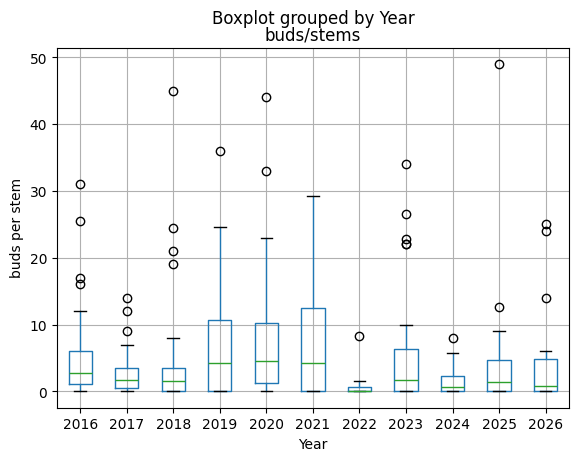

In [4]:
df.boxplot(column='buds/stems', by='Year')

plt.xlabel("Year")
plt.ylabel("buds per stem")
plt.show()

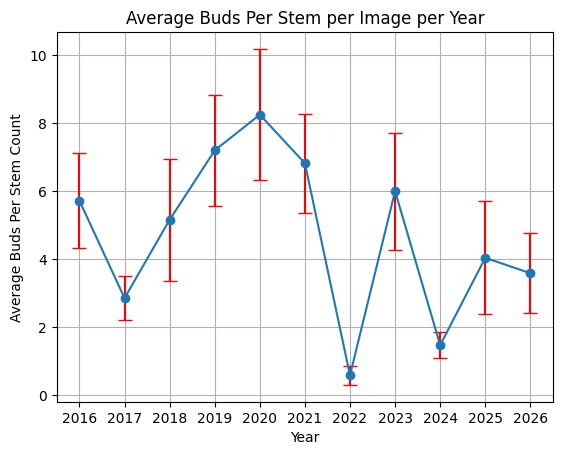

In [5]:
# line plot for mean each year with standard errors
yearly_buds_stems_mean = df.groupby('Year')['buds/stems'].mean()
yearly_buds_stems_se = df.groupby('Year')['buds/stems'].sem()

plt.errorbar(yearly_buds_stems_mean.index, yearly_buds_stems_mean.values, yerr=yearly_buds_stems_se.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Buds Per Stem Count")
plt.title("Average Buds Per Stem per Image per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

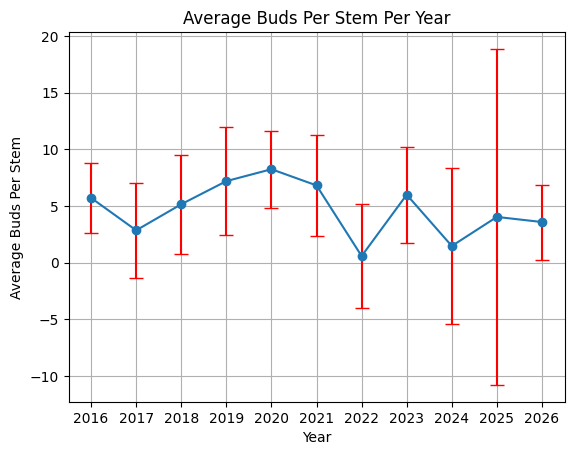

In [6]:
# line plot for mean each year with standard deviation
yearly_buds_stems_std = df.groupby('Year')['Stem Count'].std()

plt.errorbar(yearly_buds_stems_mean.index, yearly_buds_stems_mean.values, yerr=yearly_buds_stems_std.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Buds Per Stem")
plt.title("Average Buds Per Stem Per Year")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

## Statistical Analysis

In [7]:
# check if anova test is valid
# check normality
model = LinearRegression()
model.fit(df[['Year']], df[['buds/stems']])

predictions = model.predict(df[['Year']])
residuals = df[['buds/stems']] - predictions

stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)

# check homogeneity of variances
buds_stems_2016 = df.loc[df['Year'] == 2016, 'buds/stems']
buds_stems_2017 = df.loc[df['Year'] == 2017, 'buds/stems']
buds_stems_2018 = df.loc[df['Year'] == 2018, 'buds/stems']
buds_stems_2019 = df.loc[df['Year'] == 2019, 'buds/stems']
buds_stems_2020 = df.loc[df['Year'] == 2020, 'buds/stems']
buds_stems_2021 = df.loc[df['Year'] == 2021, 'buds/stems']
buds_stems_2022 = df.loc[df['Year'] == 2022, 'buds/stems']
buds_stems_2023 = df.loc[df['Year'] == 2023, 'buds/stems']
buds_stems_2024 = df.loc[df['Year'] == 2024, 'buds/stems']
buds_stems_2025 = df.loc[df['Year'] == 2025, 'buds/stems']
buds_stems_2026 = df.loc[df['Year'] == 2026, 'buds/stems']
data = [buds_stems_2016, buds_stems_2017, buds_stems_2018, buds_stems_2019, buds_stems_2020, buds_stems_2021, buds_stems_2022, buds_stems_2023, buds_stems_2024, buds_stems_2025, buds_stems_2026]

stat1, p1 = stats.levene(buds_stems_2016, buds_stems_2017, buds_stems_2018, buds_stems_2019, buds_stems_2020, buds_stems_2021, buds_stems_2022, buds_stems_2023, buds_stems_2024, buds_stems_2025, buds_stems_2026)
print("Levene's p-value:", p1)

Shapiro-Wilk p-value: 2.628279699971196e-25
Levene's p-value: 0.002060137903123675


The Shapiro-Wilk p-value is less than 0.05 meaning that the data is not normally distributed. The Levene's p-value is also less than 0.05 meaning that the data does not have homogeneity of variences. Since the data is neither normally distributed nor has homogeneity of variences, a non parametric test must be done.

In [8]:
# since anova is not valid do kruskal wallis
h_stat, p2 = stats.kruskal(buds_stems_2016, buds_stems_2017, buds_stems_2018, buds_stems_2019, buds_stems_2020, buds_stems_2021, buds_stems_2022, buds_stems_2023, buds_stems_2024, buds_stems_2025, buds_stems_2026)
print("H-statistic:", h_stat)
print("P-Value:", p2)

H-statistic: 40.83270607473503
P-Value: 1.2080171552254694e-05


Since the p-value is less than 0.05, there is a significant difference between at least some of the means of the buds per stem per image each year. A non parametric pairwise comparison test will be done to see the differences between each year.

In [9]:
# do dunns test
dunn_results = sp.posthoc_dunn(data, p_adjust='bonferroni')
dresults = pd.DataFrame(dunn_results)
dresults.columns = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dresults.index =  ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dresults

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
2016,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000331,1.000000,0.181144,1.000000,1.000000
2017,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.054588,1.000000,1.000000,1.000000,1.000000
2018,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.119873,1.000000,1.000000,1.000000,1.000000
2019,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000971,1.000000,0.374442,1.000000,1.000000
2020,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000045,1.000000,0.045058,0.965085,1.000000
2021,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.001909,1.000000,0.586360,1.000000,1.000000
2022,0.000331,0.054588,0.119873,0.000971,0.000045,0.001909,1.000000,0.059879,1.000000,0.579457,0.531009
2023,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.059879,1.000000,1.000000,1.000000,1.000000
2024,0.181144,1.000000,1.000000,0.374442,0.045058,0.586360,1.000000,1.000000,1.000000,1.000000,1.000000
2025,1.000000,1.000000,1.000000,1.000000,0.965085,1.000000,0.579457,1.000000,1.000000,1.000000,1.000000


Significant differences: 2016 and 2022, 2019 and 2022, 2020 and 2022, 2020 and 2024. There are only a couple of pairs of years that are significantly different

## Remove Outliers

In [10]:
# get outliers
clean_data = []

for year in df['Year'].unique():
    year_data = df[df['Year'] == year]

    Q1 = year_data['buds/stems'].quantile(0.25)
    Q3 = year_data['buds/stems'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    clean_year = year_data[
        (year_data['buds/stems'] >= lower) &
        (year_data['buds/stems'] <= upper)
    ]

    clean_data.append(clean_year)

df_no_outliers = pd.concat(clean_data)

In [11]:
df_no_outliers.info()

<class 'pandas.DataFrame'>
Index: 304 entries, 0 to 329
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       304 non-null    int64  
 1   Year        304 non-null    int64  
 2   Bud Count   304 non-null    int64  
 3   Stem Count  304 non-null    int64  
 4   buds/stems  304 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 14.2 KB


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Image       330 non-null    int64  
 1   Year        330 non-null    int64  
 2   Bud Count   330 non-null    int64  
 3   Stem Count  330 non-null    int64  
 4   buds/stems  330 non-null    float64
dtypes: float64(1), int64(4)
memory usage: 13.0 KB


26 outliers removed

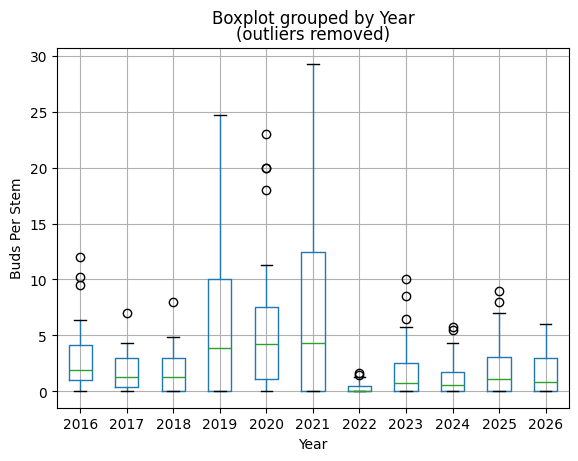

In [13]:
# box plot by year
df_no_outliers.boxplot(column='buds/stems', by='Year')

plt.xlabel("Year")
plt.ylabel("Buds Per Stem")
plt.title("(outliers removed)")
plt.show()

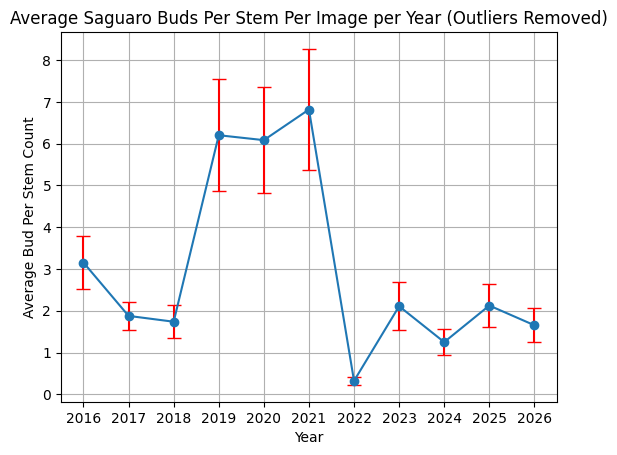

In [14]:
# line plot for mean each year with standard errors
yearly_buds_mean1 = df_no_outliers.groupby('Year')['buds/stems'].mean()
yearly_buds_se1 = df_no_outliers.groupby('Year')['buds/stems'].sem()

plt.errorbar(yearly_buds_mean1.index, yearly_buds_mean1.values, yerr=yearly_buds_se1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Per Stem Count")
plt.title("Average Saguaro Buds Per Stem Per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

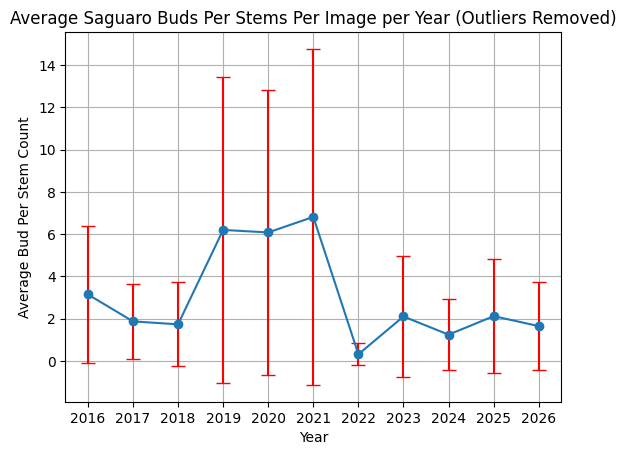

In [15]:
# line plot for mean each year with standard deviation
yearly_buds_std1 = df_no_outliers.groupby('Year')['buds/stems'].std()

plt.errorbar(yearly_buds_mean1.index, yearly_buds_mean1.values, yerr=yearly_buds_std1.values, marker='o', ecolor='red', capsize=5)

plt.xlabel("Year")
plt.ylabel("Average Bud Per Stem Count")
plt.title("Average Saguaro Buds Per Stems Per Image per Year (Outliers Removed)")
plt.xticks([2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 
           ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026'])
plt.grid()
plt.show()

In [16]:
# check if anova test is valid
# check normality
model1 = LinearRegression()
model1.fit(df_no_outliers[['Year']], df_no_outliers[['buds/stems']])

predictions1 = model1.predict(df_no_outliers[['Year']])
residuals1 = df_no_outliers[['buds/stems']] - predictions1

stat2, p3 = stats.shapiro(residuals1)
print("Shapiro-Wilk p-value:", p3)

# check homogeneity of variances
obuds_2016 = df_no_outliers.loc[df['Year'] == 2016, 'buds/stems']
obuds_2017 = df_no_outliers.loc[df['Year'] == 2017, 'buds/stems']
obuds_2018 = df_no_outliers.loc[df['Year'] == 2018, 'buds/stems']
obuds_2019 = df_no_outliers.loc[df['Year'] == 2019, 'buds/stems']
obuds_2020 = df_no_outliers.loc[df['Year'] == 2020, 'buds/stems']
obuds_2021 = df_no_outliers.loc[df['Year'] == 2021, 'buds/stems']
obuds_2022 = df_no_outliers.loc[df['Year'] == 2022, 'buds/stems']
obuds_2023 = df_no_outliers.loc[df['Year'] == 2023, 'buds/stems']
obuds_2024 = df_no_outliers.loc[df['Year'] == 2024, 'buds/stems']
obuds_2025 = df_no_outliers.loc[df['Year'] == 2025, 'buds/stems']
obuds_2026 = df_no_outliers.loc[df['Year'] == 2026, 'buds/stems']
data1 = [obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026]

stat3, p4 = stats.levene(obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026)
print("Levene's p-value:", p4)

Shapiro-Wilk p-value: 6.381274831275534e-23
Levene's p-value: 9.814760669825139e-15


The Shapiro-Wilk p-value is less than 0.05 meaning that the data is not normally distributed. The Levene's p-value is also less than 0.05 meaning that the data does not have homogeneity of variences. Since the data is neither normally distributed nor has homogeneity of variences, a non parametric test must be done.

In [17]:
# do kruskal test on all years without outliers
h_stat1, p_val1 = stats.kruskal(obuds_2016, obuds_2017, obuds_2018, obuds_2019, obuds_2020, obuds_2021, obuds_2022, obuds_2023, obuds_2024, obuds_2025, obuds_2026)

print("h-statistic:", h_stat1)
print("p-value:", p_val1)

h-statistic: 45.66671191904842
p-value: 1.6480039391935436e-06


Since the p-value is less than 0.05, there is a significant difference between at least some of the means of buds per stems per image each year. A non parametric pairwise comparison test will be done to see the differences between each year

In [18]:
# dunn test on data without outliers
dunn_results1 = sp.posthoc_dunn(data1, p_adjust='bonferroni')
dunn_results1.columns = ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1.index =  ['2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026']
dunn_results1

,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
2016,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.001273,1.000000,0.650372,1.000000,1.000000
2017,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.083756,1.000000,1.000000,1.000000,1.000000
2018,1.000000,1.000000,1.000000,1.000000,0.697113,1.000000,0.753965,1.000000,1.000000,1.000000,1.000000
2019,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000255,1.000000,0.266261,1.000000,1.000000
2020,1.000000,1.000000,0.697113,1.000000,1.000000,1.000000,0.000021,0.620368,0.048279,0.576297,0.308789
2021,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000195,1.000000,0.234636,1.000000,1.000000
2022,0.001273,0.083756,0.753965,0.000255,0.000021,0.000195,1.000000,0.972858,1.000000,0.696600,1.000000
2023,1.000000,1.000000,1.000000,1.000000,0.620368,1.000000,0.972858,1.000000,1.000000,1.000000,1.000000
2024,0.650372,1.000000,1.000000,0.266261,0.048279,0.234636,1.000000,1.000000,1.000000,1.000000,1.000000
2025,1.000000,1.000000,1.000000,1.000000,0.576297,1.000000,0.696600,1.000000,1.000000,1.000000,1.000000


Significantly different: 2022 and 2016, 2022 and 2019, 2022 and 2020, 2022 and 20211, 2020 and 2024. There is one more pair of years that is statistically different when outliers are removed. 